In [8]:
# =============================
# CELL 1 - Import Libraries
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Setting style visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Semua library berhasil diimport!")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")


Semua library berhasil diimport!
Pandas version: 2.3.3
Scikit-learn version: 1.7.2


In [2]:
# =============================
# CELL 2 - Load Dataset
# =============================
df = pd.read_csv('../data/Mall_Customers.csv')

# Cek 5 baris pertama
print("Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\n--- 5 Baris Pertama ---")
df.head()

Dataset berhasil dimuat!
Jumlah baris: 200
Jumlah kolom: 5

--- 5 Baris Pertama ---


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
# =============================
# CELL 3 - Eksplorasi Awal
# =============================
print("=== INFO DATASET ===")
print(df.info())

print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

print("\n=== CEK MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== CEK DUPLIKAT ===")
print(f"Jumlah duplikat: {df.duplicated().sum()}")

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

=== STATISTIK DESKRIPTIF ===
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000       

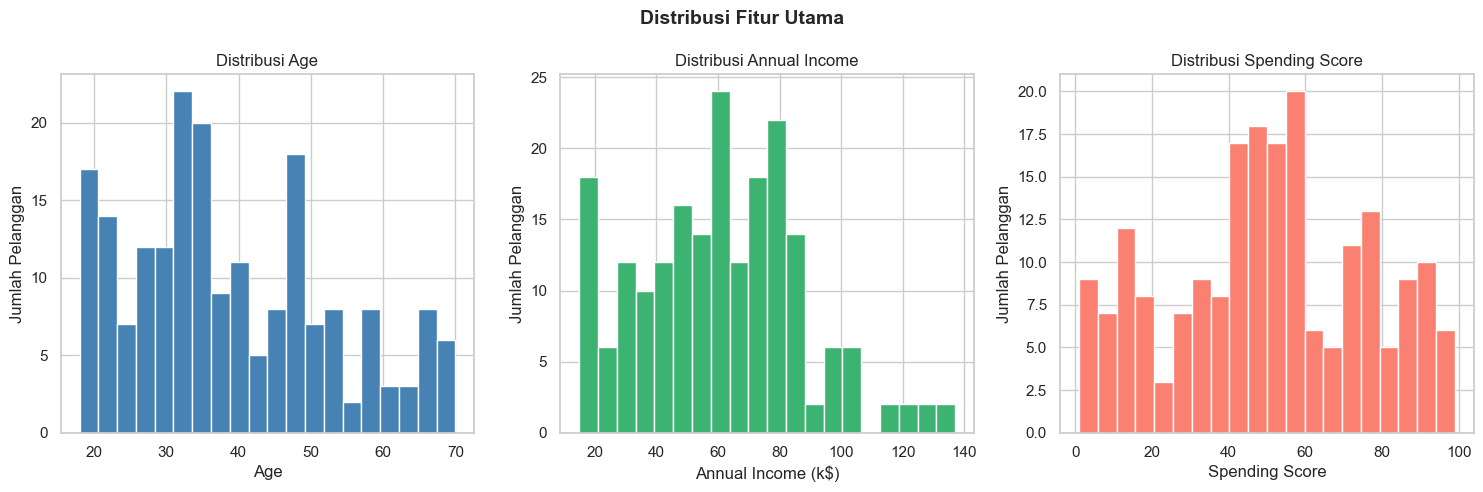

Visualisasi distribusi berhasil!


In [10]:
# =============================
# CELL 4 - Visualisasi Distribusi
# =============================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Distribusi Age
axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Jumlah Pelanggan')

# Distribusi Annual Income
axes[1].hist(df['Annual Income (k$)'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Distribusi Annual Income')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Jumlah Pelanggan')

# Distribusi Spending Score
axes[2].hist(df['Spending Score (1-100)'], bins=20, color='salmon', edgecolor='white')
axes[2].set_title('Distribusi Spending Score')
axes[2].set_xlabel('Spending Score')
axes[2].set_ylabel('Jumlah Pelanggan')

plt.suptitle('Distribusi Fitur Utama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualisasi distribusi berhasil!")

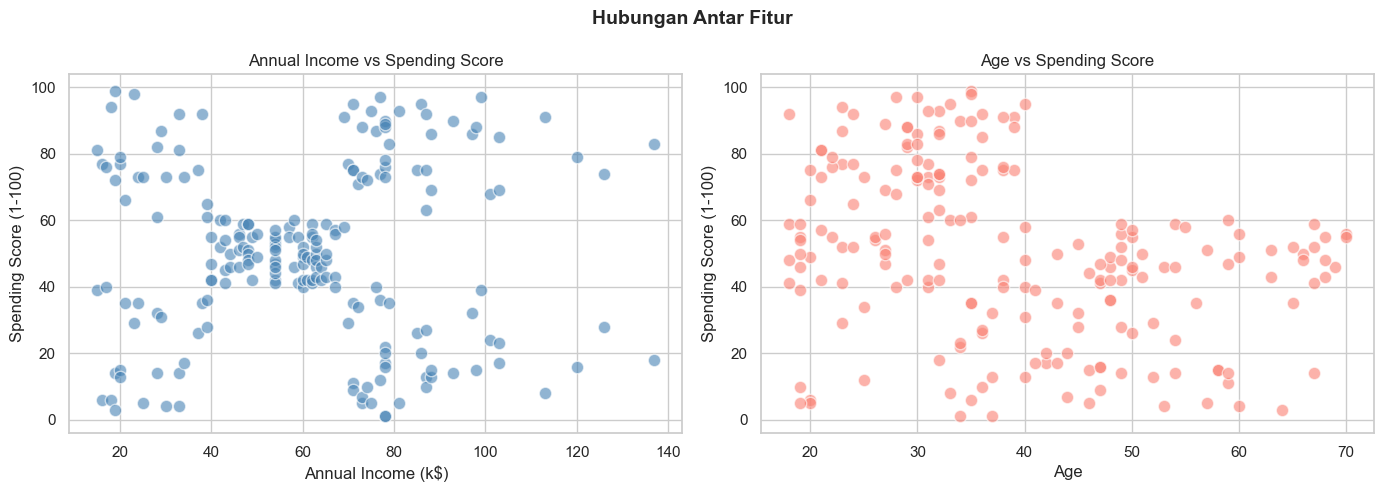

Scatter plot berhasil!


In [5]:
# =============================
# CELL 5 - Scatter Plot
# =============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income vs Spending Score
axes[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                color='steelblue', alpha=0.6, edgecolors='white', s=80)
axes[0].set_title('Annual Income vs Spending Score')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')

# Age vs Spending Score
axes[1].scatter(df['Age'], df['Spending Score (1-100)'],
                color='salmon', alpha=0.6, edgecolors='white', s=80)
axes[1].set_title('Age vs Spending Score')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score (1-100)')

plt.suptitle('Hubungan Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Scatter plot berhasil!")

In [6]:
# =============================
# CELL 6 - Preprocessing
# =============================

# Pilih fitur untuk clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()

# Normalisasi dengan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Simpan scaler untuk deployment nanti
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')

print("Preprocessing selesai!")
print(f"Shape data: {X_scaled.shape}")
print(f"\nSebelum scaling:")
print(X.describe().round(2))
print(f"\nSetelah scaling (mean ≈ 0, std ≈ 1):")
print(pd.DataFrame(X_scaled, columns=['Annual Income', 'Spending Score']).describe().round(2))

Preprocessing selesai!
Shape data: (200, 2)

Sebelum scaling:
       Annual Income (k$)  Spending Score (1-100)
count              200.00                  200.00
mean                60.56                   50.20
std                 26.26                   25.82
min                 15.00                    1.00
25%                 41.50                   34.75
50%                 61.50                   50.00
75%                 78.00                   73.00
max                137.00                   99.00

Setelah scaling (mean ≈ 0, std ≈ 1):
       Annual Income  Spending Score
count         200.00          200.00
mean           -0.00           -0.00
std             1.00            1.00
min            -1.74           -1.91
25%            -0.73           -0.60
50%             0.04           -0.01
75%             0.67            0.89
max             2.92            1.89


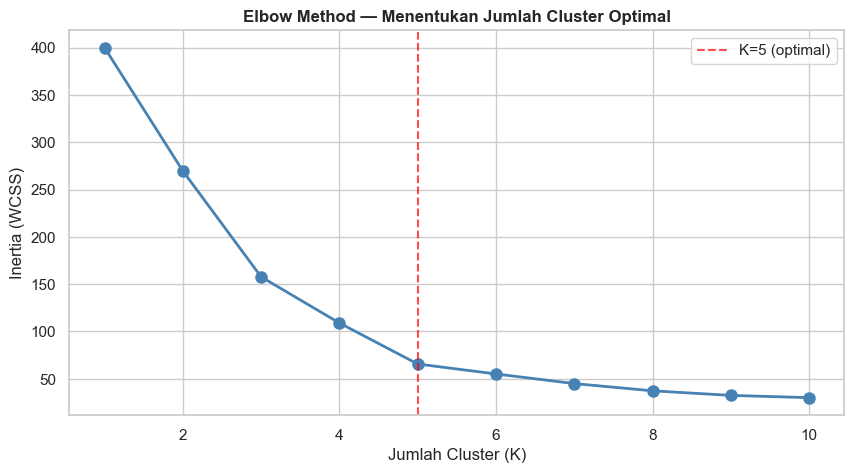

Elbow Method selesai!

Nilai Inertia per K:
  K=1: 400.00
  K=2: 269.69
  K=3: 157.70
  K=4: 108.92
  K=5: 65.57
  K=6: 55.06
  K=7: 44.86
  K=8: 37.23
  K=9: 32.39
  K=10: 29.98


In [11]:
# =============================
# CELL 7 - Elbow Method
# =============================
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5 (optimal)')
plt.title('Elbow Method — Menentukan Jumlah Cluster Optimal', fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (WCSS)')
plt.legend()
plt.savefig('../data/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("Elbow Method selesai!")
print("\nNilai Inertia per K:")
for k, val in zip(K_range, inertia):
    print(f"  K={k}: {val:.2f}")

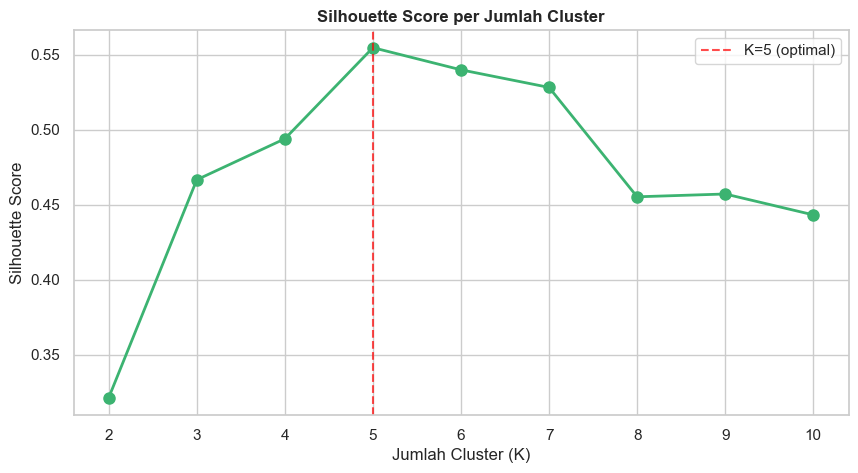

Silhouette Score selesai!

Silhouette Score per K:
  K=2: 0.3213
  K=3: 0.4666
  K=4: 0.4939
  K=5: 0.5547
  K=6: 0.5399
  K=7: 0.5281
  K=8: 0.4552
  K=9: 0.4571
  K=10: 0.4432


In [12]:
# =============================
# CELL 8 - Silhouette Score
# =============================
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot Silhouette Score
plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='mediumseagreen', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', alpha=0.7, label='K=5 (optimal)')
plt.title('Silhouette Score per Jumlah Cluster', fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.savefig('../data/silhouette_score.png', dpi=150, bbox_inches='tight')
plt.show()

print("Silhouette Score selesai!")
print("\nSilhouette Score per K:")
for k, val in zip(K_range, silhouette_scores):
    print(f"  K={k}: {val:.4f}")

In [13]:
# =============================
# CELL 9 - K-Means Clustering
# =============================
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Simpan model
joblib.dump(kmeans, '../models/kmeans_model.pkl')

# Evaluasi
sil_score = silhouette_score(X_scaled, df['Cluster'])
db_score = davies_bouldin_score(X_scaled, df['Cluster'])

print("K-Means Clustering selesai!")
print(f"\nSilhouette Score : {sil_score:.4f} (target > 0.5)")
print(f"Davies-Bouldin   : {db_score:.4f} (target < 0.5)")
print(f"\nJumlah anggota per cluster:")
print(df['Cluster'].value_counts().sort_index())

K-Means Clustering selesai!

Silhouette Score : 0.5547 (target > 0.5)
Davies-Bouldin   : 0.5722 (target < 0.5)

Jumlah anggota per cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


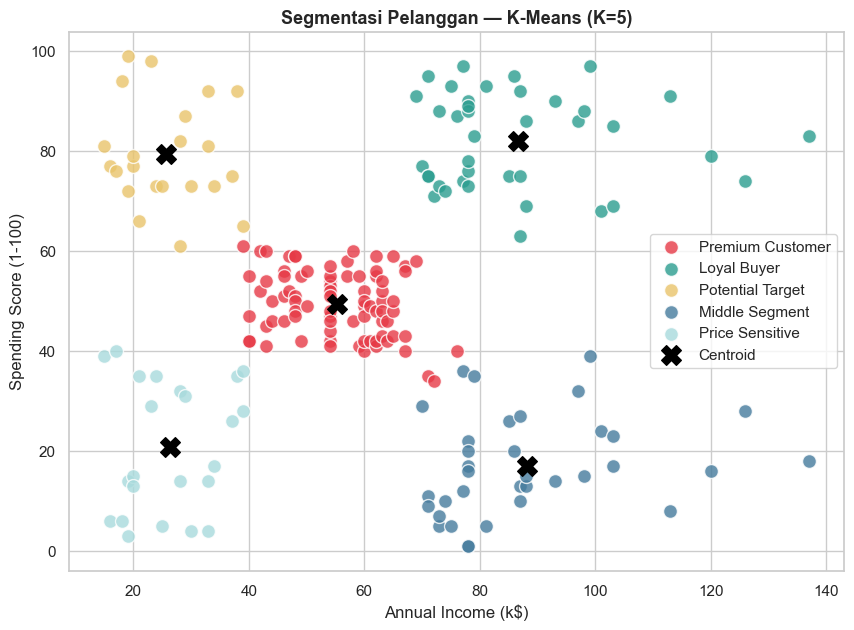

Visualisasi cluster berhasil!


In [14]:
# =============================
# CELL 10 - Visualisasi Cluster
# =============================
colors = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#A8DADC']
labels_map = {
    0: 'Premium Customer',
    1: 'Loyal Buyer',
    2: 'Potential Target',
    3: 'Middle Segment',
    4: 'Price Sensitive'
}

plt.figure(figsize=(10, 7))

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        c=colors[i], label=labels_map[i],
        s=100, alpha=0.8, edgecolors='white'
    )

# Plot centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroid')

plt.title('Segmentasi Pelanggan — K-Means (K=5)', fontweight='bold', fontsize=13)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.savefig('../data/cluster_result.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualisasi cluster berhasil!")

In [15]:
# =============================
# CELL 11 - Analisis Cluster
# =============================
df['Cluster Label'] = df['Cluster'].map(labels_map)

summary = df.groupby('Cluster Label')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
summary['Jumlah Pelanggan'] = df.groupby('Cluster Label')['Cluster'].count()

print("=== RINGKASAN KARAKTERISTIK TIAP SEGMEN ===\n")
print(summary.to_string())

=== RINGKASAN KARAKTERISTIK TIAP SEGMEN ===

                    Age  Annual Income (k$)  Spending Score (1-100)  Jumlah Pelanggan
Cluster Label                                                                        
Loyal Buyer       32.69               86.54                   82.13                39
Middle Segment    41.11               88.20                   17.11                35
Potential Target  25.27               25.73                   79.36                22
Premium Customer  42.72               55.30                   49.52                81
Price Sensitive   45.22               26.30                   20.91                23


In [17]:
# =============================
# CELL 12 - DBSCAN
# =============================
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

# Evaluasi (exclude noise = -1)
mask = df['Cluster_DBSCAN'] != -1
sil_dbscan = silhouette_score(X_scaled[mask], df['Cluster_DBSCAN'][mask])
db_dbscan = davies_bouldin_score(X_scaled[mask], df['Cluster_DBSCAN'][mask])

print("DBSCAN selesai!")
print(f"\nJumlah cluster terbentuk : {len(set(df['Cluster_DBSCAN'])) - 1} (exclude noise)")
print(f"Jumlah noise/outlier     : {(df['Cluster_DBSCAN'] == -1).sum()}")
print(f"Silhouette Score         : {sil_dbscan:.4f}")
print(f"Davies-Bouldin           : {db_dbscan:.4f}")

DBSCAN selesai!

Jumlah cluster terbentuk : 2 (exclude noise)
Jumlah noise/outlier     : 8
Silhouette Score         : 0.3876
Davies-Bouldin           : 0.7889


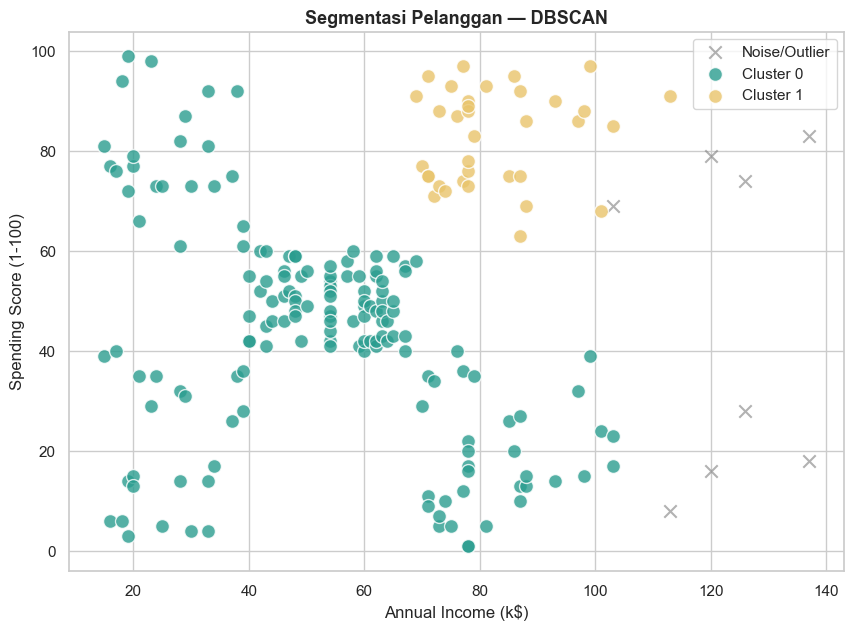

In [18]:
# =============================
# CELL 13 - Visualisasi DBSCAN
# =============================
plt.figure(figsize=(10, 7))

unique_labels = sorted(set(df['Cluster_DBSCAN']))
colors_db = ['#E63946', '#2A9D8F', '#E9C46A', '#457B9D', '#A8DADC']

for i, label in enumerate(unique_labels):
    cluster_data = df[df['Cluster_DBSCAN'] == label]
    if label == -1:
        plt.scatter(cluster_data['Annual Income (k$)'],
                    cluster_data['Spending Score (1-100)'],
                    c='gray', marker='x', s=80, label='Noise/Outlier', alpha=0.6)
    else:
        plt.scatter(cluster_data['Annual Income (k$)'],
                    cluster_data['Spending Score (1-100)'],
                    c=colors_db[i % len(colors_db)], s=100,
                    alpha=0.8, edgecolors='white', label=f'Cluster {label}')

plt.title('Segmentasi Pelanggan — DBSCAN', fontweight='bold', fontsize=13)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.savefig('../data/dbscan_result.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# =============================
# CELL 14 - Perbandingan Model
# =============================
comparison = pd.DataFrame({
    'Metrik': ['Silhouette Score', 'Davies-Bouldin Index', 'Jumlah Cluster', 'Noise/Outlier'],
    'K-Means': [f'{sil_score:.4f}', f'{db_score:.4f}', '5', '0'],
    'DBSCAN': [f'{sil_dbscan:.4f}', f'{db_dbscan:.4f}',
               str(len(set(df['Cluster_DBSCAN'])) - 1),
               str((df['Cluster_DBSCAN'] == -1).sum())]
})

print("=== PERBANDINGAN K-MEANS vs DBSCAN ===\n")
print(comparison.to_string(index=False))
print("\n=== KESIMPULAN ===")
if sil_score > sil_dbscan:
    print("K-Means lebih unggul berdasarkan Silhouette Score")
    print("→ K-Means dipilih sebagai model final")
else:
    print("DBSCAN lebih unggul berdasarkan Silhouette Score")
    print("→ DBSCAN dipilih sebagai model final")

=== PERBANDINGAN K-MEANS vs DBSCAN ===

              Metrik K-Means DBSCAN
    Silhouette Score  0.5547 0.3876
Davies-Bouldin Index  0.5722 0.7889
      Jumlah Cluster       5      2
       Noise/Outlier       0      8

=== KESIMPULAN ===
K-Means lebih unggul berdasarkan Silhouette Score
→ K-Means dipilih sebagai model final


In [21]:
# =============================
# CELL 15 - Kesimpulan & Rekomendasi
# =============================
rekomendasi = {
    'Premium Customer'  : 'Promo eksklusif, loyalty program premium, early access produk baru',
    'Loyal Buyer'       : 'Program reward, cashback, tingkatkan engagement & retensi',
    'Potential Target'  : 'Kampanye edukasi produk, upselling, penawaran bundle premium',
    'Middle Segment'    : 'Promo reguler, bundle package, diskon seasonal',
    'Price Sensitive'   : 'Flash sale, diskon besar, voucher, program cicilan'
}

print("=== KESIMPULAN AKHIR ===\n")
print(f"Model terpilih   : K-Means Clustering (K=5)")
print(f"Silhouette Score : {sil_score:.4f}")
print(f"Davies-Bouldin   : {db_score:.4f}")
print("\n=== REKOMENDASI STRATEGI PEMASARAN ===\n")

for i, (segment, strategi) in enumerate(rekomendasi.items()):
    count = (df['Cluster Label'] == segment).sum()
    print(f"Cluster {i} — {segment} ({count} pelanggan)")
    print(f"  → {strategi}\n")

=== KESIMPULAN AKHIR ===

Model terpilih   : K-Means Clustering (K=5)
Silhouette Score : 0.5547
Davies-Bouldin   : 0.5722

=== REKOMENDASI STRATEGI PEMASARAN ===

Cluster 0 — Premium Customer (81 pelanggan)
  → Promo eksklusif, loyalty program premium, early access produk baru

Cluster 1 — Loyal Buyer (39 pelanggan)
  → Program reward, cashback, tingkatkan engagement & retensi

Cluster 2 — Potential Target (22 pelanggan)
  → Kampanye edukasi produk, upselling, penawaran bundle premium

Cluster 3 — Middle Segment (35 pelanggan)
  → Promo reguler, bundle package, diskon seasonal

Cluster 4 — Price Sensitive (23 pelanggan)
  → Flash sale, diskon besar, voucher, program cicilan

